# 2D Optimization Training with TensorBoard

This notebook demonstrates how to run the optimization loop using the `OptimizationTrainer` and visualize progress using TensorBoard directly within the notebook.

In [1]:
%load_ext autoreload
%autoreload 2


In [39]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
# import torch

from diffmeshopt.opt2d.optimize import ContourRefiner
from diffmeshopt.opt2d.props import OptimizationProps, SamplingProps, TemplateProps
from diffmeshopt.opt2d.trainer import OptimizationTrainer, TrainerConfig


# 1. Load Data
data_path = Path("/workspace/diffmeshopt/data/2d_training_data.pkl")
if not data_path.exists():
    print(f"Data file {data_path} not found. Please run src/generate_2d_data.py first.")
else:
    print(f"Loading data from {data_path}...")
    data = joblib.load(data_path)
    image_np = -data["image"]  # Invert intensity if needed based on previous notebooks
    contour_np = data["contour"]
    gt_contour_np = data["gt"]

# 2. Setup Refiner
opt_props = OptimizationProps(
    lr=0.05,
    w_edge=10,
    w_laplacian=50,
    w_sigma_reg=0.0,
    w_template_shape=0.5,
    w_template_smooth=10,
)
sampl_props = SamplingProps(num_samples=51, sample_length=1.0)
template_props = TemplateProps(sigma=0.75, peak_dist=4.5, num_samples=51, min_peak_ratio=4)

refiner = ContourRefiner(
    image=image_np,
    initial_contour=contour_np,
    optimization_props=opt_props,
    sampling_props=sampl_props,
    template_props=template_props,
    template_mode="global",
)
# refiner.to(device)

Loading data from /workspace/diffmeshopt/data/2d_training_data.pkl...


In [40]:
# 3. Setup Trainer

train_config = TrainerConfig(
    output_dir="/workspace/diffmeshopt/output/experiment_tb",
    image=image_np,
    gt_contour=contour_np,
    log_interval=10,
    log_image_interval=50,
    save_interval=50,
    use_tensorboard=False,
)

trainer = OptimizationTrainer(
    refiner=refiner,
    config=train_config,
)


/workspace/diffmeshopt/.pixi/envs/default/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /workspace/diffmeshopt/.pixi/envs/default/lib/python ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


In [41]:
# 5. Run Training
trainer.fit(steps_to_run=500)

/workspace/diffmeshopt/.pixi/envs/default/lib/python3.13/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /workspace/diffmeshopt/output/experiment_tb/2026-01-26_08-52-36 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In [42]:
trainer.fit(steps_to_run=2000)

Restoring states from the checkpoint path at /workspace/diffmeshopt/output/experiment_tb/2026-01-26_08-52-36/last.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Restored all states from the checkpoint at /workspace/diffmeshopt/output/experiment_tb/2026-01-26_08-52-36/last.ckpt
/workspace/diffmeshopt/.pixi/envs/default/lib/python3.13/site-packages/lightning/pytorch/loops/training_epoch_loop.py:224: You're resuming from a checkpoint that ended before the epoch ended and your dataloader is not resumable. This can cause unreliable results if further training is done. Consider using an end-of-epoch checkpoint or make your dataloader resumable by implementing the `state_dict` / `load_state_dict` interface.


In [43]:
refiner.template_model.get_params()

{'peak_dist': tensor(3.8609, grad_fn=<MulBackward0>),
 'sigma': tensor(0.9648, grad_fn=<ExpBackward0>)}

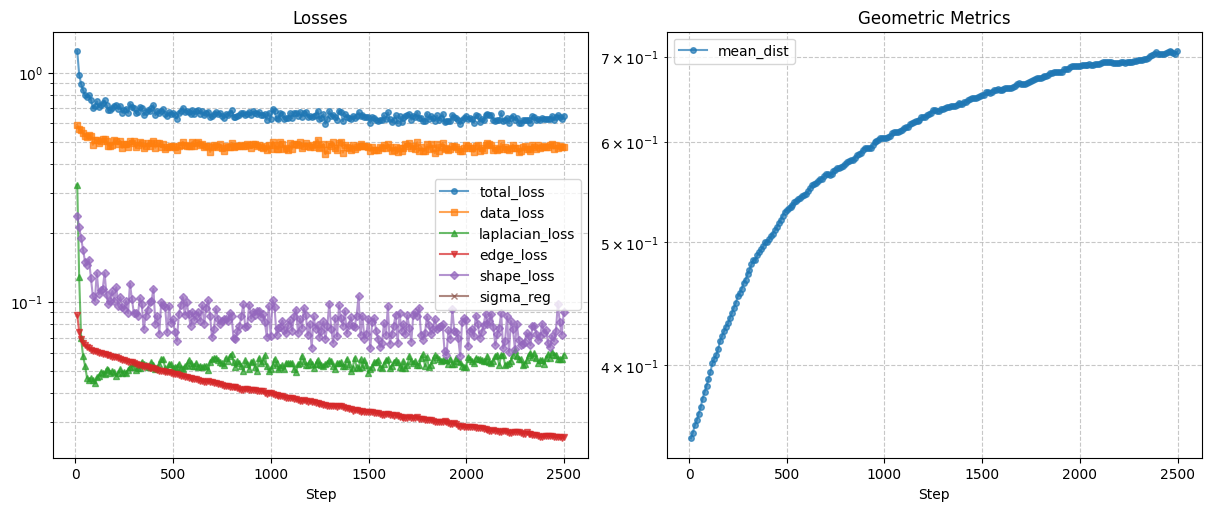

In [44]:
trainer.plot_metrics()

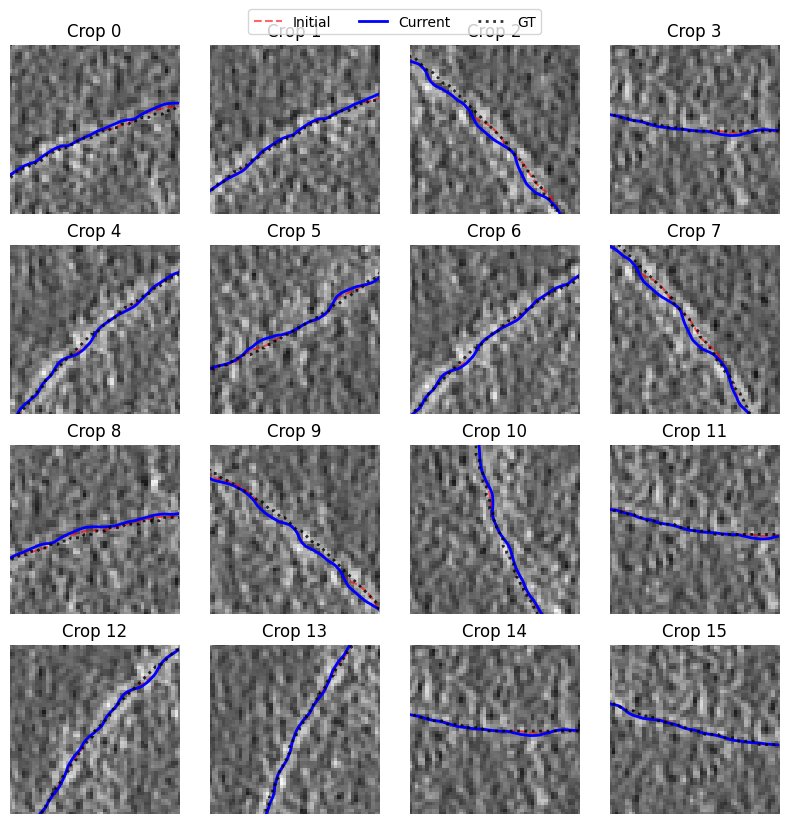

In [45]:
trainer.plot_image()

In [46]:
template_params = refiner.template_model.get_params()

updated_template_props = template_props.model_copy(
    update={
        "peak_dist": template_params["peak_dist"].detach().cpu().numpy(),
        "sigma": template_params["sigma"].detach().cpu().numpy(),
    }
)
template_props, updated_template_props

(TemplateProps(peak_dist=4.5, sigma=0.75, amp=1.0, min_peak_ratio=4.0, num_samples=51, num_control_points=10, neural_hidden_dim=32, neural_num_layers=2),
 TemplateProps(peak_dist=array(3.8608575, dtype=float32), sigma=array(0.964754, dtype=float32), amp=1.0, min_peak_ratio=4.0, num_samples=51, num_control_points=10, neural_hidden_dim=32, neural_num_layers=2))

In [47]:
import diffmeshopt.opt2d.vis as vis2d

In [48]:
import diffmeshopt.opt2d.sampling as sampling2d

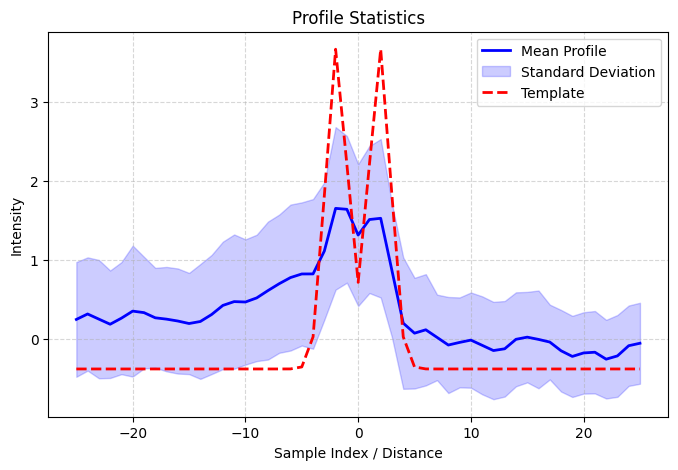

In [49]:
sample_profiles, _, _ = sampling2d.sample_profiles_stochastic(
    sampling2d._convert_to_tensor(image_np),
    sampling2d._convert_to_tensor(contour_np),
    sampling_props=sampl_props,
)

sample_profiles = sample_profiles.detach().cpu().numpy()

fig, ax = plt.subplots(figsize=(8, 5))

vis2d.plot_profile_statistics(sample_profiles, ax=ax, template_props=updated_template_props)
plt.show()

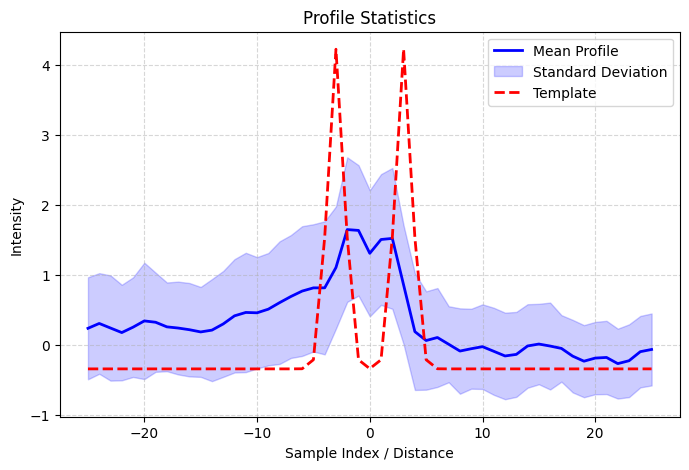

In [50]:
fig, ax = plt.subplots(figsize=(8, 5))

vis2d.plot_profile_statistics(sample_profiles, ax=ax)
plt.show()